In [4]:
from protein_interpretability.rsa import (
    load_representations,
    load_distance_matrix,
    seq_sep_matrix,
    layerwise_rsa,
    layerwise_partial_rsa,
    cross_layer_cka,
    mutation_divergence,
    perturbation_profile,
    rsa_divergence,)

In [6]:
from pathlib import Path

seq_11947 = Path("/Users/thomasbush/Downloads/interpretability/seq_11947")
seq_15513 = Path("/Users/thomasbush/Downloads/interpretability/seq_15513")

reps11947 = load_representations(seq_11947/ "hidden_reps.pt")
reps15513 = load_representations(seq_15513/ "hidden_reps.pt")


In [17]:
import torch
X = torch.stack(list(reps11947['layer_reps'].values()))
Y = torch.stack(list(reps15513['layer_reps'].values()))

In [19]:
from protein_interpretability.rsa.metrics import linear_cka
Lx = X.shape[0]
Ly = Y.shape[0]
M = torch.empty(Lx, Ly, device=X.device, dtype=X.dtype)
for i in range(Lx):
    for j in range(Ly):
        M[i, j] = linear_cka(X[i], Y[j])

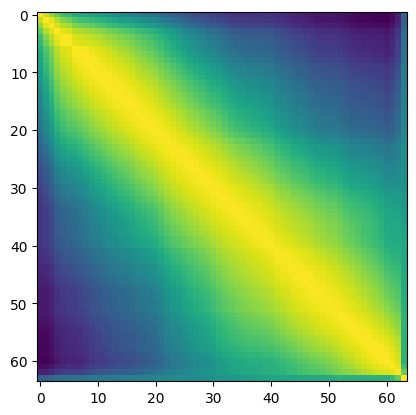

In [21]:
import matplotlib.pyplot as plt
plt.imshow(M)
plt.show()


In [9]:
div = mutation_divergence(reps11947['layer_reps'], reps15513['layer_reps'], method="cosine")
cka1 = cross_layer_cka(reps11947['layer_reps'])
cka2 = cross_layer_cka(reps15513['layer_reps'])

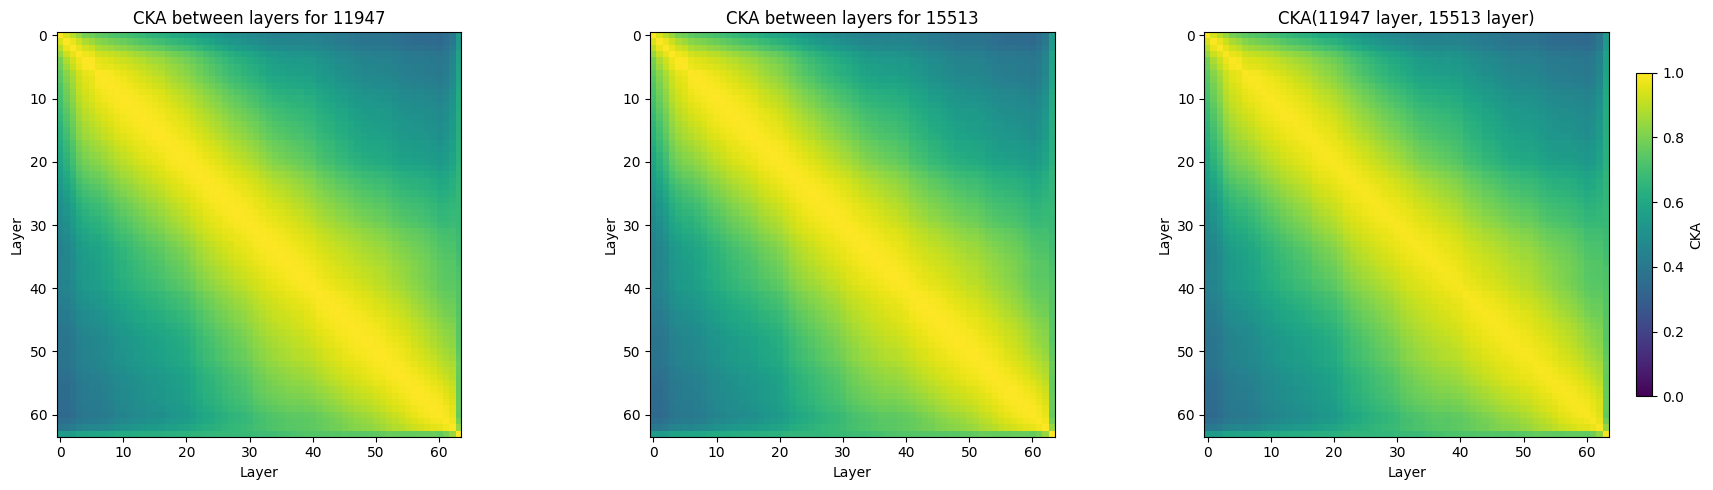

: 

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cka, name in zip(axes[:2], [cka1, cka2], ["11947", "15513"]):
    im = ax.imshow(cka['cka'], vmin=0, vmax=1, cmap='viridis')
    ax.set_xlabel('Layer')
    ax.set_ylabel('Layer')
    ax.set_title(f'CKA between layers for {name}')

# Add the M matrix to the third axis
im_M = axes[2].imshow(M.cpu().numpy(), vmin=0, vmax=1, cmap='viridis')
axes[2].set_xlabel('Layer')
axes[2].set_ylabel('Layer')
axes[2].set_title('CKA(11947 layer, 15513 layer)')

# Colorbars

fig.colorbar(im_M, ax=axes[2], label='CKA', shrink=0.8)

plt.tight_layout()
plt.show()

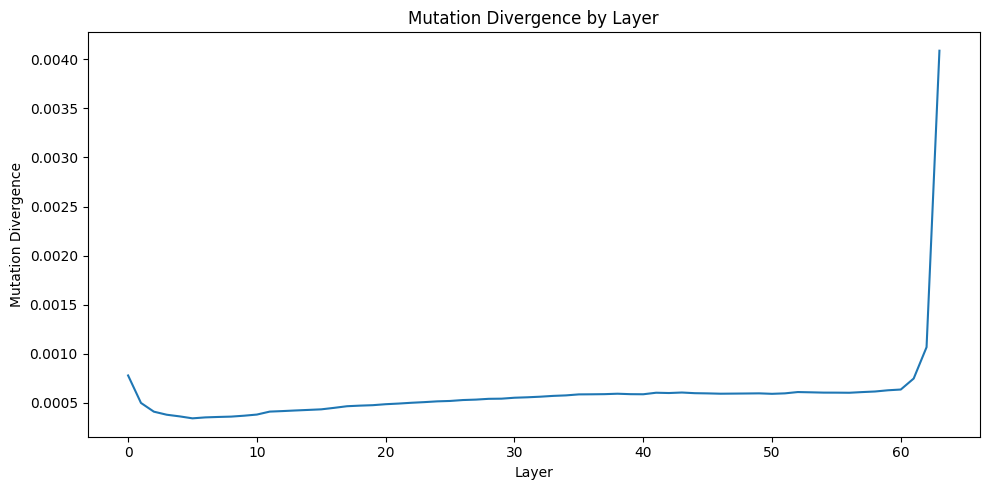

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(div["layers"], div["divergence"])
plt.xlabel("Layer")
plt.ylabel("Mutation Divergence")
plt.title("Mutation Divergence by Layer")
plt.tight_layout()
plt.show()
